<a href="https://colab.research.google.com/github/eniompw/microgpt/blob/dev/microgpt_fast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MicroGPT — PyTorch (Colab T4 GPU)

The most atomic way to train and run inference for a GPT in pure PyTorch.
Based on [@karpathy](https://github.com/karpathy)'s microgpt.

> **Runtime:** Go to **Runtime → Change runtime type → T4 GPU** before running.

## 1. GPU Setup and Library Imports

In [1]:
import os
import random
import json
import torch
import torch.nn.functional as F

# Reproducibility
random.seed(42)
torch.manual_seed(42)

# Device setup — will use T4 GPU on Colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 2. Dataset Download and Preparation

In [2]:
import pandas as pd

if not os.path.exists('input.txt'):
    print("Downloading TinyStories dataset from HuggingFace...")
    df = pd.read_parquet("hf://datasets/karpathy/tinystories-gpt4-clean/tinystories_gpt4_clean.parquet")
    stories = df['text'].iloc[20000:25000].tolist()  # 5000 stories
    with open('input.txt', 'w') as f:
        for story in stories:
            f.write(json.dumps(story) + '\n')
    print(f"Saved {len(stories)} stories to input.txt")
else:
    print("input.txt already exists, skipping download.")

docs = [json.loads(line) for line in open('input.txt') if line.strip()]
random.shuffle(docs)
print(f"num docs: {len(docs)}")
print(f"sample doc: {docs[0][:120]}...")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Saved 5000 stories to input.txt
num docs: 5000
sample doc: Ben and Lily were playing in the farm with their new friend, Mira the mule. Mira was very strong and gentle, and she lik...


## 3. Tokenizer Setup

In [3]:
# Character-level vocabulary — all 74 chars present in the dataset
uchars = sorted('\n !"$\',-.' + '0123456789:;?' + 'ABCDEFGHIJKLMNOPQRSTUVWXYZ' + 'abcdefghijklmnopqrstuvwxyz')
BOS = len(uchars)          # special Beginning-of-Sequence token id
vocab_size = len(uchars) + 1
print(f"vocab size: {vocab_size}")
print(f"BOS token id: {BOS}")

# Encode / decode helpers
stoi = {ch: i for i, ch in enumerate(uchars)}
encode = lambda s: [stoi[ch] for ch in s]
decode = lambda ids: ''.join(uchars[i] for i in ids)

# Sanity check
sample_text = "Once upon a time"
encoded = encode(sample_text)
decoded = decode(encoded)
print(f"encode('{sample_text}') → {encoded}")
print(f"decode(...)           → '{decoded}'")

vocab size: 75
BOS token id: 74
encode('Once upon a time') → [36, 61, 50, 52, 1, 68, 63, 62, 61, 1, 48, 1, 67, 56, 60, 52]
decode(...)           → 'Once upon a time'


## 4. Model Hyperparameters and Parameter Initialization

In [4]:
import math

# ── Hyperparameters ───────────────────────────────────────────────────────────
n_layer    = 6       # transformer depth
n_embd     = 256     # embedding dim
block_size = 256     # context window
n_head     = 8       # attention heads
head_dim   = n_embd // n_head
batch_size = 64      # sequences per gradient step

# ── Weight init ──────────────────────────────────────────────────────────────
matrix = lambda nout, nin: torch.randn(nout, nin, device=device) * 0.02

wte = matrix(vocab_size, n_embd)
layers = []
for _ in range(n_layer):
    layers.append({
        'attn_wq': matrix(n_embd, n_embd),
        'attn_wk': matrix(n_embd, n_embd),
        'attn_wv': matrix(n_embd, n_embd),
        'attn_wo': matrix(n_embd, n_embd),
        'mlp_fc1': matrix(4 * n_embd, n_embd),
        'mlp_fc2': matrix(n_embd, 4 * n_embd),
    })

params = [wte] + [p for layer in layers for p in layer.values()]
for p in params:
    p.requires_grad_(True)

total_params = sum(p.numel() for p in params)
print(f"num params: {total_params:,}")
print(f"tokens per iter: {batch_size * block_size:,}")

num params: 4,737,792
tokens per iter: 16,384


## 5. Model Architecture Definition

Llama-style transformer: RMSNorm, RoPE, flash attention, weight tying.
The core forward pass stays explicit for teaching; only boilerplate is factored out elsewhere.

In [5]:
def rmsnorm(x):
    """RMSNorm along last dim — works for any shape."""
    return x * (x.pow(2).mean(-1, keepdim=True) + 1e-5).rsqrt()

# ── RoPE (Rotary Position Embeddings) ────────────────────────────────────────
freqs = 1.0 / (10000.0 ** (torch.arange(0, head_dim, 2, device=device).float() / head_dim))
freqs = torch.outer(torch.arange(block_size, device=device).float(), freqs)
rope_cos, rope_sin = freqs.cos(), freqs.sin()   # (block_size, head_dim//2)

def apply_rope(x, cos, sin):
    """x: (B,T,H,D) or (H,D). cos/sin: (T,D//2) or (D//2,)"""
    d = x.dtype
    x = x.float().unflatten(-1, (-1, 2))
    x_r, x_i = x[..., 0], x[..., 1]
    if x.dim() == 5:  # batched
        cos = cos.view(1, -1, 1, cos.shape[-1])
        sin = sin.view(1, -1, 1, sin.shape[-1])
    return torch.stack([x_r*cos - x_i*sin, x_r*sin + x_i*cos], -1).flatten(-2).to(d)

# ── Batched forward (for training) ───────────────────────────────────────────
def gpt_train(tokens):
    """tokens: (B, T) long -> logits: (B, T, vocab_size)"""
    bsz, seqlen = tokens.shape
    x = rmsnorm(F.embedding(tokens, wte))
    cos, sin = rope_cos[:seqlen], rope_sin[:seqlen]
    for layer in layers:
        r = x
        x = rmsnorm(x)
        q = F.linear(x, layer['attn_wq']).view(bsz, seqlen, n_head, head_dim)
        k = F.linear(x, layer['attn_wk']).view(bsz, seqlen, n_head, head_dim)
        v = F.linear(x, layer['attn_wv']).view(bsz, seqlen, n_head, head_dim)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        x = F.scaled_dot_product_attention(
            q.transpose(1, 2), k.transpose(1, 2), v.transpose(1, 2), is_causal=True
        ).transpose(1, 2).contiguous().view(bsz, seqlen, -1)
        x = F.linear(x, layer['attn_wo']) + r
        r = x
        x = rmsnorm(x)
        x = F.silu(F.linear(x, layer['mlp_fc1']))
        x = F.linear(x, layer['mlp_fc2']) + r
    return F.linear(rmsnorm(x), wte)   # weight-tied lm_head

gpt_train = torch.compile(gpt_train)  # fuse GPU kernels for ~2x speedup
print(f"torch.compile cache: {os.getenv('TORCHINDUCTOR_CACHE_DIR', '~/.cache/torch/inductor')}")

# ── Single-token forward (for inference with KV cache) ───────────────────────
def gpt(token_id, pos_id, keys, values):
    x = rmsnorm(wte[token_id])
    cos, sin = rope_cos[pos_id], rope_sin[pos_id]
    for li, layer in enumerate(layers):
        r = x
        x = rmsnorm(x)
        q = F.linear(x, layer['attn_wq']).view(n_head, head_dim)
        k = F.linear(x, layer['attn_wk']).view(n_head, head_dim)
        v = F.linear(x, layer['attn_wv']).view(n_head, head_dim)
        q, k = apply_rope(q, cos, sin), apply_rope(k, cos, sin)
        keys[li].append(k)
        values[li].append(v)
        x_attn = []
        for h in range(n_head):
            k_h = torch.stack([ki[h] for ki in keys[li]])
            v_h = torch.stack([vi[h] for vi in values[li]])
            x_attn.append(F.softmax(k_h @ q[h] / head_dim**0.5, dim=0) @ v_h)
        x = F.linear(torch.cat(x_attn), layer['attn_wo']) + r
        r = x
        x = rmsnorm(x)
        x = F.silu(F.linear(x, layer['mlp_fc1']))
        x = F.linear(x, layer['mlp_fc2']) + r
    return F.linear(rmsnorm(x), wte)

print("Model functions defined.")

torch.compile cache: /tmp/torchinductor_root
Model functions defined.


## 6. Training Loop

Total tokens: 4,051,708


W0406 11:23:29.929000 11297 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode


step    0/3500 | loss 5.2302 | lr 0.00e+00 | 16.5s
step  100/3500 | loss 2.2199 | lr 5.00e-04 | 36.7s
step  200/3500 | loss 1.5364 | lr 1.00e-03 | 41.6s
step  300/3500 | loss 1.2795 | lr 9.98e-04 | 46.5s
step  400/3500 | loss 1.1414 | lr 9.92e-04 | 51.3s
step  500/3500 | loss 1.0510 | lr 9.82e-04 | 56.3s
step  600/3500 | loss 1.0004 | lr 9.68e-04 | 61.3s
step  700/3500 | loss 0.9604 | lr 9.50e-04 | 66.4s
step  800/3500 | loss 0.9285 | lr 9.29e-04 | 71.5s
step  900/3500 | loss 0.9367 | lr 9.04e-04 | 76.6s
step 1000/3500 | loss 0.8701 | lr 8.76e-04 | 81.7s
step 1100/3500 | loss 0.8533 | lr 8.45e-04 | 86.9s
step 1200/3500 | loss 0.8300 | lr 8.11e-04 | 92.2s
step 1300/3500 | loss 0.8302 | lr 7.75e-04 | 97.6s
step 1400/3500 | loss 0.8341 | lr 7.37e-04 | 103.0s
step 1500/3500 | loss 0.7874 | lr 6.97e-04 | 108.6s
step 1600/3500 | loss 0.7705 | lr 6.56e-04 | 114.1s
step 1700/3500 | loss 0.7504 | lr 6.14e-04 | 119.8s
step 1800/3500 | loss 0.7677 | lr 5.71e-04 | 125.5s
step 1900/3500 | loss 0.76

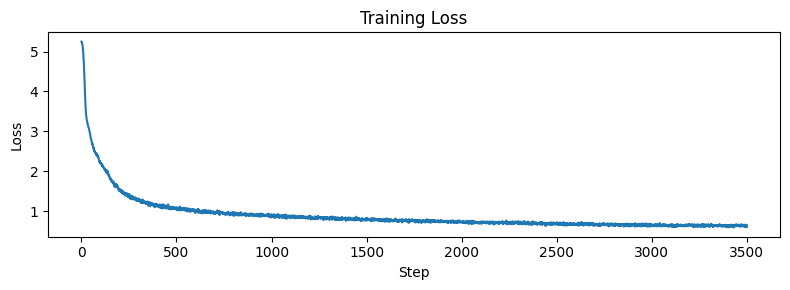

In [6]:
import time
import matplotlib.pyplot as plt

# ── Prepare token stream ─────────────────────────────────────────────────────
all_tokens = [BOS]
for doc in docs:
    all_tokens.extend(encode(doc) + [BOS])
all_tokens = torch.tensor(all_tokens, dtype=torch.long, device=device)
print(f"Total tokens: {len(all_tokens):,}")

def get_batch():
    starts = torch.randint(0, len(all_tokens) - block_size - 1, (batch_size,))
    xb = torch.stack([all_tokens[i : i + block_size] for i in starts])
    yb = torch.stack([all_tokens[i + 1 : i + block_size + 1] for i in starts])
    return xb, yb

# ── Optimizer: AdamW ─────────────────────────────────────────────────────────
num_steps     = 3500
warmup_steps  = 200
learning_rate = 1e-3
min_lr        = 1e-4   # 10% of peak — prevents wasted steps at tail

def get_lr(step):
    if step < warmup_steps:
        return learning_rate * step / warmup_steps
    progress = (step - warmup_steps) / (num_steps - warmup_steps)
    return min_lr + (learning_rate - min_lr) * 0.5 * (1 + math.cos(math.pi * progress))

optimizer = torch.optim.AdamW(params, lr=learning_rate, betas=(0.9, 0.95), eps=1e-10)

# Mixed precision (float16 on T4)
scaler = torch.amp.GradScaler('cuda')

# ── Training loop ────────────────────────────────────────────────────────────
loss_history = []
t0 = time.time()

for step in range(num_steps + 1):
    lr_t = get_lr(step)
    for g in optimizer.param_groups:
        g['lr'] = lr_t

    if step % 100 == 0:
        xb, yb = get_batch()
        with torch.no_grad(), torch.amp.autocast('cuda', dtype=torch.float16):
            el = F.cross_entropy(gpt_train(xb).view(-1, vocab_size), yb.view(-1)).item()
        print(f"step {step:4d}/{num_steps} | loss {el:.4f} | lr {lr_t:.2e} | {time.time()-t0:.1f}s")

    if step >= num_steps:
        break

    optimizer.zero_grad(set_to_none=True)
    xb, yb = get_batch()
    with torch.amp.autocast('cuda', dtype=torch.float16):
        loss = F.cross_entropy(gpt_train(xb).view(-1, vocab_size), yb.view(-1))
    scaler.scale(loss).backward()
    scaler.unscale_(optimizer)
    torch.nn.utils.clip_grad_norm_(params, 1.0)
    scaler.step(optimizer)
    scaler.update()
    loss_history.append(loss.item())

print(f"\nDone in {time.time()-t0:.1f}s")
plt.figure(figsize=(8, 3))
plt.plot(loss_history)
plt.xlabel('Step'); plt.ylabel('Loss'); plt.title('Training Loss')
plt.tight_layout(); plt.show()

## 7. Inference and Text Generation

In [7]:
temperature = 0.7   # (0, 1] — lower = more focused, higher = more random
num_samples = 5
max_new_tokens = 200  # generate up to this many tokens per sample

def generate_sample(max_new_tokens=200, temperature=0.7):
    keys = [[] for _ in range(n_layer)]
    values = [[] for _ in range(n_layer)]
    token_id = BOS
    sample = []
    with torch.no_grad():
        for pos_id in range(max_new_tokens):
            logits = gpt(token_id, min(pos_id, block_size - 1), keys, values)
            probs = F.softmax(logits[:vocab_size] / temperature, dim=-1)
            token_id = torch.multinomial(probs, 1).item()
            if token_id == BOS:
                break
            sample.append(uchars[token_id])
    return ''.join(sample)

print("--- inference (hallucinated stories) ---\n")
t0 = time.time()
for sample_idx in range(num_samples):
    print(f"sample {sample_idx+1}:\n{generate_sample(max_new_tokens, temperature)}\n")
print(f"Done in {time.time()-t0:.1f}s")

--- inference (hallucinated stories) ---

sample 1:
Once upon a time there was a little girl named Amy. She had a minute on her hand. Every day, she would come to her mom and dad. One day, she wanted to make her mom sort and say her folded the water.
A

sample 2:
Once upon a time, there was a little girl named Lucy. She had a big sheet that she loved very much. One day, she saw a little girl named Lucy came to the shop. As she walked, she saw a small dog named

sample 3:
Once upon a time, in a small town, there lived a girl named Lily. She had a pretty bow that she loved to read. One day, she found a beautiful box. It was a soft bear. She did not want to sit under it.

sample 4:
Once upon a time, there was a little girl named Mia. Mia loved to play outside in the sun. One day, Mia saw a big bowl of wood on a tree. She wanted to stay passing the girl will not see.
Mia took the

sample 5:
Once upon a time, there was a little girl named Emma. She loved to play with her toys and drink it e